# 📊 Análise Exploratória de Dados (EDA)
## Dataset: Salários de Profissionais Brasileiros

**UC Aprendizado de Máquina 2026/1**

---

### Objetivo
Compreender a estrutura e qualidade dos dados antes de qualquer modelagem.  
Seguindo o processo **CRISP-DM**, esta etapa responde às perguntas:

- Quais são as variáveis e seus tipos?
- Existem valores ausentes ou inválidos?
- Como o salário se distribui? Há outliers?
- Quais variáveis têm maior relação com o salário?
- Existem padrões por região, escolaridade ou profissão?

---

### Estrutura do notebook

| Seção | Conteúdo |
|---|---|
| 1. Setup | Imports e carregamento |
| 2. Visão geral | Shape, tipos, amostra |
| 3. Qualidade | Nulos, inconsistências |
| 4. Distribuições | Histogramas, boxplots |
| 5. Variáveis categóricas | Frequências, salário por grupo |
| 6. Correlações | Heatmap e scatter |
| 7. Insights | Conclusões para a modelagem |


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Formatador de eixo Y em R$
def fmt_brl(x, pos=None):
    return f"R$ {x:,.0f}".replace(",", ".")

SEED = 42
DATA_PATH = "../dataset_salarios_brasil.csv"


## 2. Carregamento e Visão Geral

In [2]:
df_raw = pd.read_csv(DATA_PATH)

In [3]:
df_raw.isnull().sum()

Idade               289
Anos_Experiencia    298
Escolaridade          0
Segunda_Lingua        0
Terceira_Lingua       0
Regiao                0
Profissao             0
Salario             297
dtype: int64

In [4]:
df = df_raw
df = pd.read_csv(DATA_PATH)

# Forçar tipos numéricos corretos (CSV pode trazer como object)
df["Salario"]          = pd.to_numeric(df["Salario"],          errors="coerce")
df["Idade"]            = pd.to_numeric(df["Idade"],            errors="coerce")
df["Anos_Experiencia"] = pd.to_numeric(df["Anos_Experiencia"], errors="coerce")

print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head(8)


Shape: 15,000 linhas × 8 colunas


,Idade,Anos_Experiencia,Escolaridade,Segunda_Lingua,Terceira_Lingua,Regiao,Profissao,Salario
0,56.0,22.0,Superior,Inglês,Italiano,Sudeste,Vendedor,NaN
1,46.0,11.0,Médio,Alemão,Francês,Sudeste,Consultor,NaN
2,32.0,26.0,Fundamental,Inglês,Nenhuma,Sul,Consultor,6606.26
3,60.0,21.0,Pós,Francês,Nenhuma,Nordeste,Policial,6673.46
4,25.0,31.0,Médio,Alemão,Espanhol,Centro-Oeste,Professor,6632.40
5,38.0,26.0,Médio,Italiano,Nenhuma,Norte,Médico,12341.06
6,56.0,1.0,Médio,Inglês,Inglês,Nordeste,Agrônomo,3174.29
7,36.0,32.0,Médio,Nenhuma,Italiano,Nordeste,Engenheiro,13165.88


In [5]:
df.dtypes.to_frame("dtype").T


,Idade,Anos_Experiencia,Escolaridade,Segunda_Lingua,Terceira_Lingua,Regiao,Profissao,Salario
dtype,float64,float64,object,object,object,object,object,float64


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Idade,14511.0,NaN,NaN,NaN,41.482806,13.800322,18.0,30.0,41.0,53.0,65.0
Anos_Experiencia,14502.0,NaN,NaN,NaN,19.476141,11.511508,0.0,10.0,19.0,30.0,39.0
Escolaridade,15000,7,Superior,4452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segunda_Lingua,15000,5,Inglês,7482,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Terceira_Lingua,15000,6,Nenhuma,8285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiao,15000,5,Sudeste,5220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profissao,15000,19,Cientista,840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salario,14503.0,NaN,NaN,NaN,13369.600829,28359.642216,1472.25,6064.06,9259.71,14077.34,768761.0


## 3. Qualidade dos Dados

Antes de qualquer análise precisamos entender o que está "quebrado" no dataset.


In [7]:
# Contagem e percentual de nulos por coluna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
qualidade = pd.DataFrame({"nulos": nulos, "% nulos": nulos_pct})
qualidade[qualidade["nulos"] > 0]


,nulos,% nulos
Idade,489,3.26
Anos_Experiencia,498,3.32
Salario,497,3.31


In [8]:
# Valores não-numéricos na coluna Salario (que viraram NaN após to_numeric)
salario_raw = pd.read_csv(DATA_PATH, usecols=["Salario"])["Salario"]
invalidos = salario_raw[pd.to_numeric(salario_raw, errors="coerce").isna()]
print(f"Valores inválidos em Salario: {len(invalidos):,}")
print()
print(invalidos.value_counts())


Valores inválidos em Salario: 497

Salario
erro    200
Name: count, dtype: int64


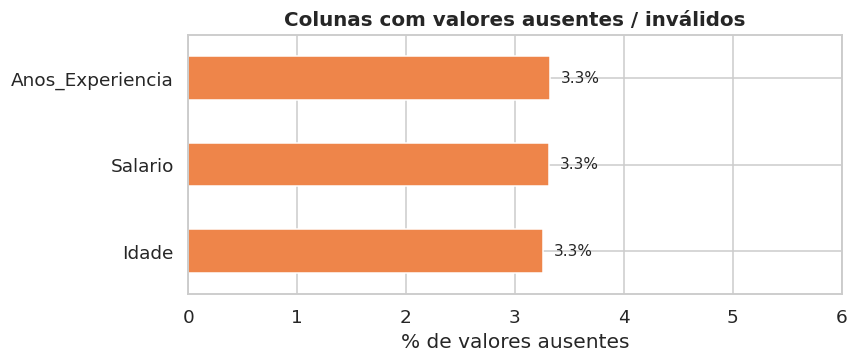

In [9]:
# Visualizar proporção de nulos
fig, ax = plt.subplots(figsize=(8, 3.5))
cols_com_nulo = qualidade[qualidade["nulos"] > 0]["% nulos"].sort_values()
cols_com_nulo.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[1], edgecolor="white")
ax.set_xlabel("% de valores ausentes")
ax.set_title("Colunas com valores ausentes / inválidos")
for bar, val in zip(ax.patches, cols_com_nulo):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.set_xlim(0, 6)
plt.tight_layout()
plt.show()


In [21]:
df["Profissao"].value_counts()

Profissao
Cientista            811
Designer             797
Engenheiro           793
Motorista            785
Policial             783
Pesquisador          773
Analista de Dados    770
Programador          766
Consultor            763
Arquiteto            763
Advogado             761
Administrador        759
Economista           752
Professor            747
Agrônomo             744
Vendedor             744
Enfermeiro           735
Médico               733
Técnico              724
Name: count, dtype: int64

Resumo de (Idade - Anos_Experiencia):
count    13568.00
mean        21.98
std         18.03
min        -21.00
25%          9.00
50%         22.00
75%         35.00
90%         46.00
95%         52.00
99%         59.00
max         65.00
Name: dif_idade_exp, dtype: float64

Registros válidos para análise: 13,568
Mantidos (>= 16): 8,557 (63.07%)
Excluídos (< 16): 5,011 (36.93%)

Amostra dos dados que vão ser excluídos (< 16):


,Idade,Anos_Experiencia,Salario,Profissao,Escolaridade,Regiao,dif_idade_exp
636,18.0,39.0,4071.95,Vendedor,Médio,Nordeste,-21.0
3049,18.0,39.0,28601.74,Engenheiro,Superior,Sudeste,-21.0
4607,18.0,39.0,8200.41,Agrônomo,Médio,Sul,-21.0
5564,18.0,39.0,6979.16,Administrador,Médio,Nordeste,-21.0
6917,18.0,39.0,12987.99,Analista de Dados,Médio,Nordeste,-21.0
11099,18.0,39.0,22482.30,Pesquisador,Superior,Sudeste,-21.0
11818,18.0,39.0,7637.41,Consultor,Médio,Centro-Oeste,-21.0
13456,18.0,39.0,5790.05,Vendedor,Superior,Sul,-21.0
14728,18.0,39.0,12770.12,Designer,Superior,Sudeste,-21.0
1811,18.0,38.0,6126.32,Técnico,Médio,Nordeste,-20.0


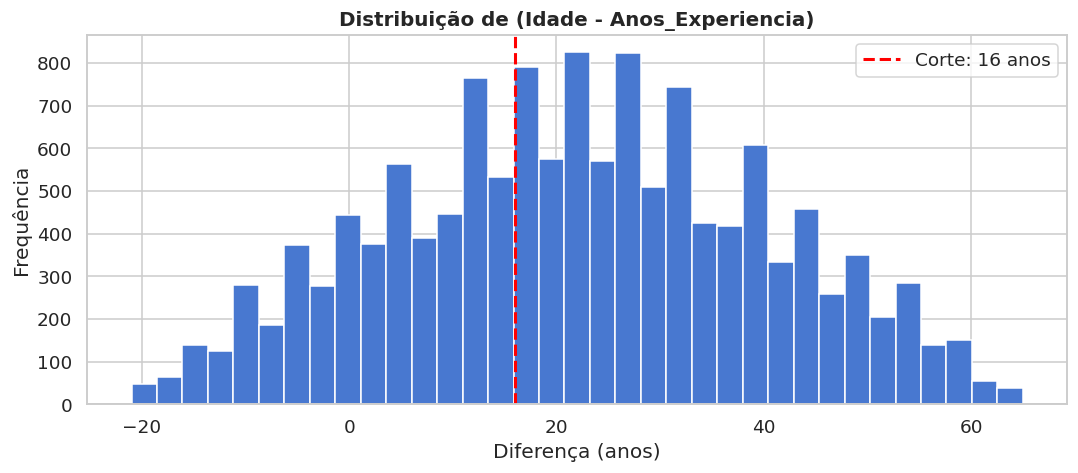

Resumo do grupo excluído (< 16):
count    5011.00
mean        3.09
std         8.87
min       -21.00
25%        -3.00
50%         5.00
75%        11.00
max        15.00
Name: dif_idade_exp, dtype: float64


In [20]:
# Análise da diferença entre idade e anos de experiência
CORTE_DIF = 16

df_diff = df[[
    "Idade",
    "Anos_Experiencia",
    "Salario",
    "Profissao",
    "Escolaridade",
    "Regiao",
]].copy()

# Remover linhas sem idade/experiência para o cálculo
df_diff = df_diff.dropna(subset=["Idade", "Anos_Experiencia"])
df_diff["dif_idade_exp"] = df_diff["Idade"] - df_diff["Anos_Experiencia"]

# Resumo da variável de diferença
resumo_diff = df_diff["dif_idade_exp"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)
print("Resumo de (Idade - Anos_Experiencia):")
print(resumo_diff)
print()

# Regra de corte
mantidos_16 = df_diff[df_diff["dif_idade_exp"] >= CORTE_DIF].copy()
excluidos_16 = df_diff[df_diff["dif_idade_exp"] < CORTE_DIF].copy()

mantidos_16 = mantidos_16.sort_values(["dif_idade_exp", "Idade"], ascending=[False, False])
excluidos_16 = excluidos_16.sort_values(["dif_idade_exp", "Idade"], ascending=[True, True])

print(f"Registros válidos para análise: {len(df_diff):,}")
print(f"Mantidos (>= {CORTE_DIF}): {len(mantidos_16):,} ({len(mantidos_16)/len(df_diff)*100:.2f}%)")
print(f"Excluídos (< {CORTE_DIF}): {len(excluidos_16):,} ({len(excluidos_16)/len(df_diff)*100:.2f}%)")
print()

print(f"Amostra dos dados que vão ser excluídos (< {CORTE_DIF}):")
display(excluidos_16.head(30))

# Visualização da distribuição + linha de corte
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(df_diff["dif_idade_exp"], bins=35, color=sns.color_palette("muted")[0], edgecolor="white")
ax.axvline(CORTE_DIF, color="red", linestyle="--", linewidth=2, label=f"Corte: {CORTE_DIF} anos")
ax.set_title("Distribuição de (Idade - Anos_Experiencia)")
ax.set_xlabel("Diferença (anos)")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

# Estatísticas apenas do grupo excluído
if not excluidos_16.empty:
    print(f"Resumo do grupo excluído (< {CORTE_DIF}):")
    print(excluidos_16["dif_idade_exp"].describe().round(2))

## 4. Distribuição das Variáveis Numéricas

### 4.1 Salário


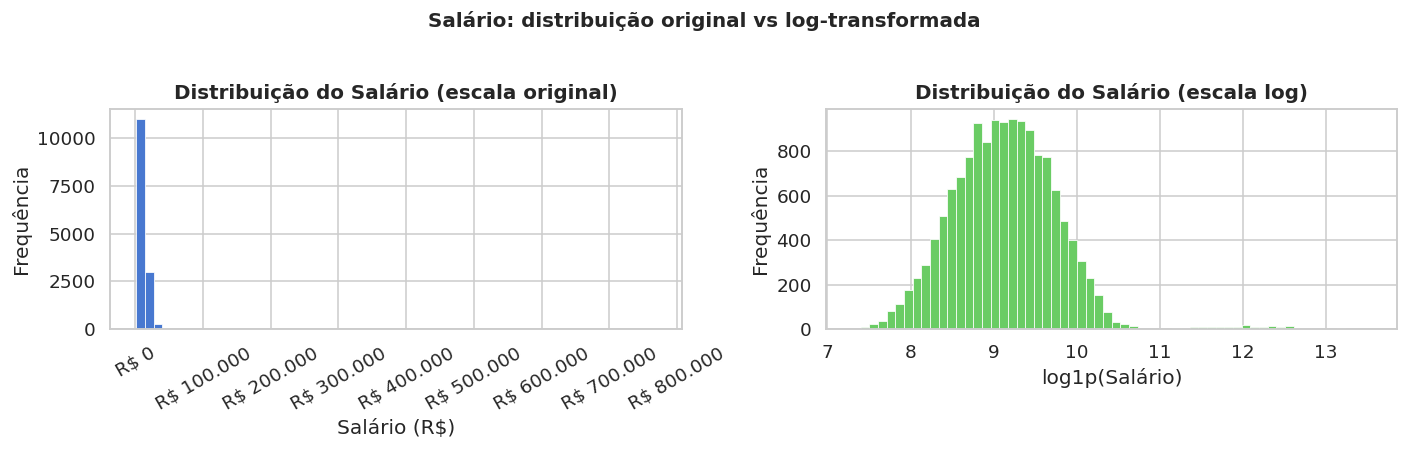

In [10]:
df = df.dropna(subset=["Salario"]).copy()
df = df[df["Salario"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma — escala original
axes[0].hist(df["Salario"], bins=60, color=sns.color_palette("muted")[0],
             edgecolor="white", linewidth=0.5)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[0].set_title("Distribuição do Salário (escala original)")
axes[0].set_xlabel("Salário (R$)")
axes[0].set_ylabel("Frequência")
axes[0].tick_params(axis="x", rotation=30)

# Histograma — escala log
axes[1].hist(np.log1p(df["Salario"]), bins=60,
             color=sns.color_palette("muted")[2], edgecolor="white", linewidth=0.5)
axes[1].set_title("Distribuição do Salário (escala log)")
axes[1].set_xlabel("log1p(Salário)")
axes[1].set_ylabel("Frequência")

plt.suptitle("Salário: distribuição original vs log-transformada", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# Estatísticas descritivas do salário
stats = df["Salario"].describe()
p99   = df["Salario"].quantile(0.99)
p995  = df["Salario"].quantile(0.995)
p998  = df["Salario"].quantile(0.998)
print("Estatísticas do Salário (R$):")
print(f"  Média    : R$ {stats['mean']:>12,.2f}")
print(f"  Mediana  : R$ {stats['50%']:>12,.2f}")
print(f"  Desvio   : R$ {stats['std']:>12,.2f}")
print(f"  Mínimo   : R$ {stats['min']:>12,.2f}")
print(f"  p99    : R$ {p99:>12,.2f}")
print(f"  p99.5    : R$ {p995:>12,.2f}")
print(f"  p99.8    : R$ {p998:>12,.2f}")
print(f"  Máximo   : R$ {stats['max']:>12,.2f}")
print()
print(f"→ Coeficiente de variação: {stats['std']/stats['mean']:.2f}  (>1 = alta dispersão)")
print(f"→ Outliers acima de R$ {p99:,.0f}: {(df['Salario'] > p99).sum()} registros")
print(f"→ Outliers acima de R$ {p995:,.0f}: {(df['Salario'] > p995).sum()} registros")
print(f"→ Outliers acima de R$ {p998:,.0f}: {(df['Salario'] > p998).sum()} registros")



Estatísticas do Salário (R$):
  Média    : R$    13,369.60
  Mediana  : R$     9,259.71
  Desvio   : R$    28,359.64
  Mínimo   : R$     1,472.25
  p99    : R$   118,328.19
  p99.5    : R$   225,216.28
  p99.8    : R$   337,502.88
  Máximo   : R$   768,761.00

→ Coeficiente de variação: 2.12  (>1 = alta dispersão)
→ Outliers acima de R$ 118,328: 146 registros
→ Outliers acima de R$ 225,216: 73 registros
→ Outliers acima de R$ 337,503: 30 registros


Média do Salário      : R$ 13,369.60
Desvio Padrão        : R$ 28,359.64

Intervalo 3σ         : [R$ -71,709.33 , R$ 98,448.53]

Outliers (3σ)        : 164 registros (1.13%)
  - Acima do limite  : 164
  - Abaixo do limite : 0

Amostra de outliers detectados:
             Profissao Escolaridade        Regiao   Salario
35         Programador          Pós         Norte  231423.6
148          Motorista    Doutorado           Sul  144065.4
173          Cientista          Pós       Sudeste  391014.0
249          Cientista        Médio           Sul  178741.2
355             Médico          Pós      Nordeste  358471.4
410          Arquiteto     Mestrado  Centro-Oeste  532871.4
710      Administrador     Superior           Sul  188056.4
791  Analista de Dados      Técnico         Norte  186562.4
810         Engenheiro    Doutorado           Sul  768761.0
974           Policial      Técnico         Norte   99533.4


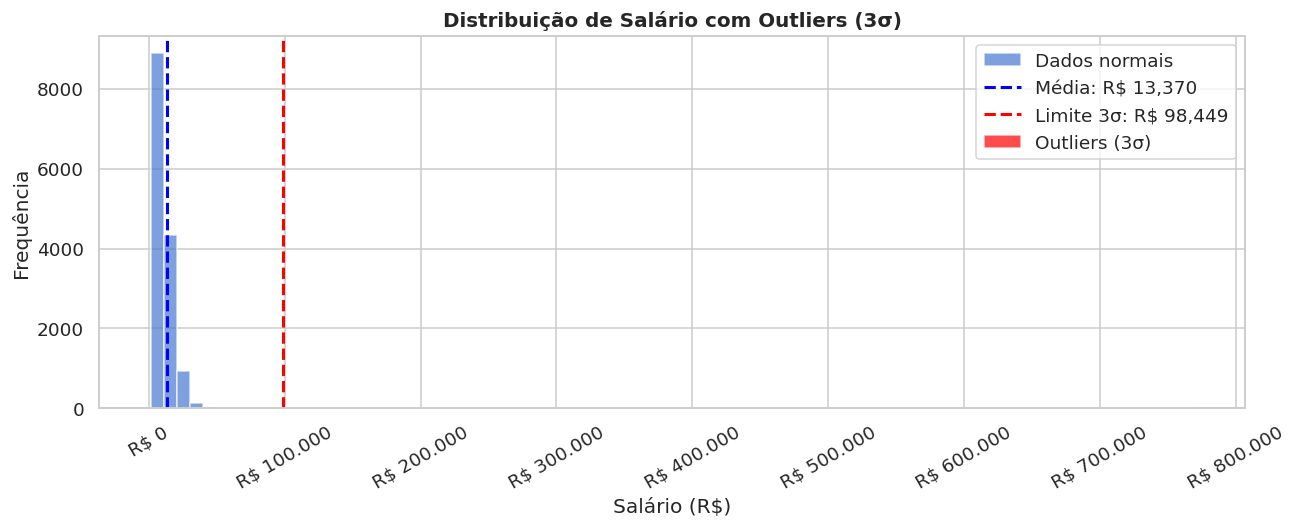

In [12]:
# Cálculo de outliers usando desvio padrão (3σ)
media_salario = df["Salario"].mean()
desvio_padrao = df["Salario"].std()

# Limites para 3 desvios padrão
limite_inferior = media_salario - 3 * desvio_padrao
limite_superior = media_salario + 3 * desvio_padrao

# Identificar outliers
outliers_3sigma = df[(df["Salario"] < limite_inferior) | (df["Salario"] > limite_superior)]

print(f"Média do Salário      : R$ {media_salario:,.2f}")
print(f"Desvio Padrão        : R$ {desvio_padrao:,.2f}")
print()
print(f"Intervalo 3σ         : [R$ {limite_inferior:,.2f} , R$ {limite_superior:,.2f}]")
print()
print(f"Outliers (3σ)        : {len(outliers_3sigma):,} registros ({len(outliers_3sigma)/len(df)*100:.2f}%)")
print(f"  - Acima do limite  : {(df['Salario'] > limite_superior).sum():,}")
print(f"  - Abaixo do limite : {(df['Salario'] < limite_inferior).sum():,}")
print()
print("Amostra de outliers detectados:")
print(outliers_3sigma[["Profissao", "Escolaridade", "Regiao", "Salario"]].head(10))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df["Salario"], bins=80, alpha=0.7, label="Dados normais", color=sns.color_palette("muted")[0], edgecolor="white")
ax.axvline(media_salario, color="blue", linestyle="--", linewidth=2, label=f"Média: R$ {media_salario:,.0f}")
ax.axvline(limite_superior, color="red", linestyle="--", linewidth=2, label=f"Limite 3σ: R$ {limite_superior:,.0f}")
ax.hist(outliers_3sigma["Salario"], bins=80, alpha=0.7, label="Outliers (3σ)", color="red", edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title("Distribuição de Salário com Outliers (3σ)")
ax.set_xlabel("Salário (R$)")
ax.set_ylabel("Frequência")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 4.2 Boxplot do Salário e detecção de outliers

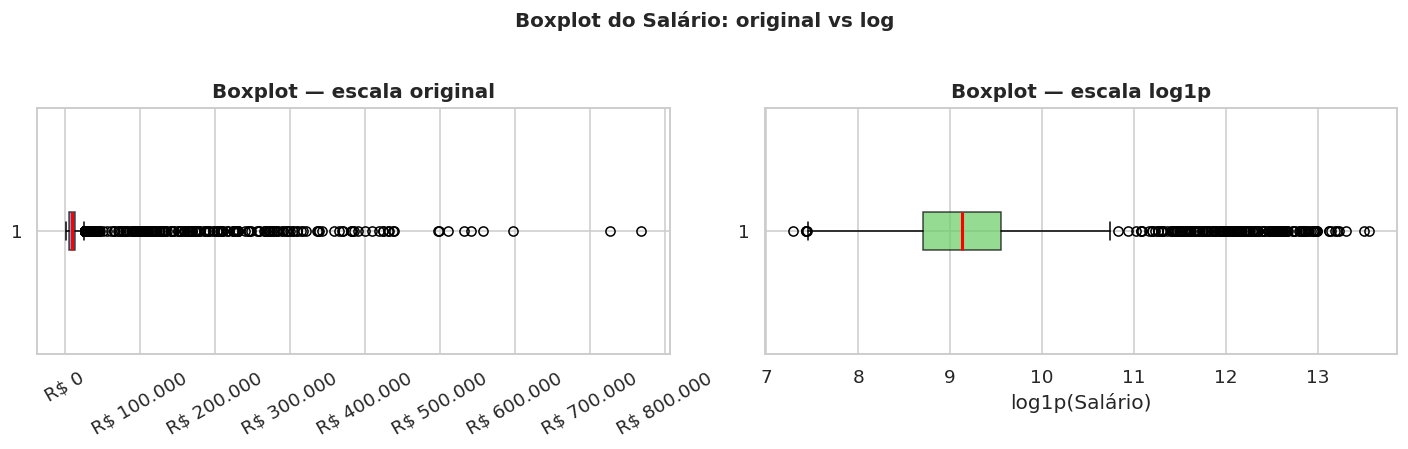

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot original
axes[0].boxplot(df["Salario"], vert=False, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette("muted")[0], alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[0].set_title("Boxplot — escala original")
axes[0].tick_params(axis="x", rotation=30)

# Boxplot log
axes[1].boxplot(np.log1p(df["Salario"]), vert=False, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette("muted")[2], alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Boxplot — escala log1p")
axes[1].set_xlabel("log1p(Salário)")

plt.suptitle("Boxplot do Salário: original vs log", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



### 4.3 Idade e Anos de Experiência

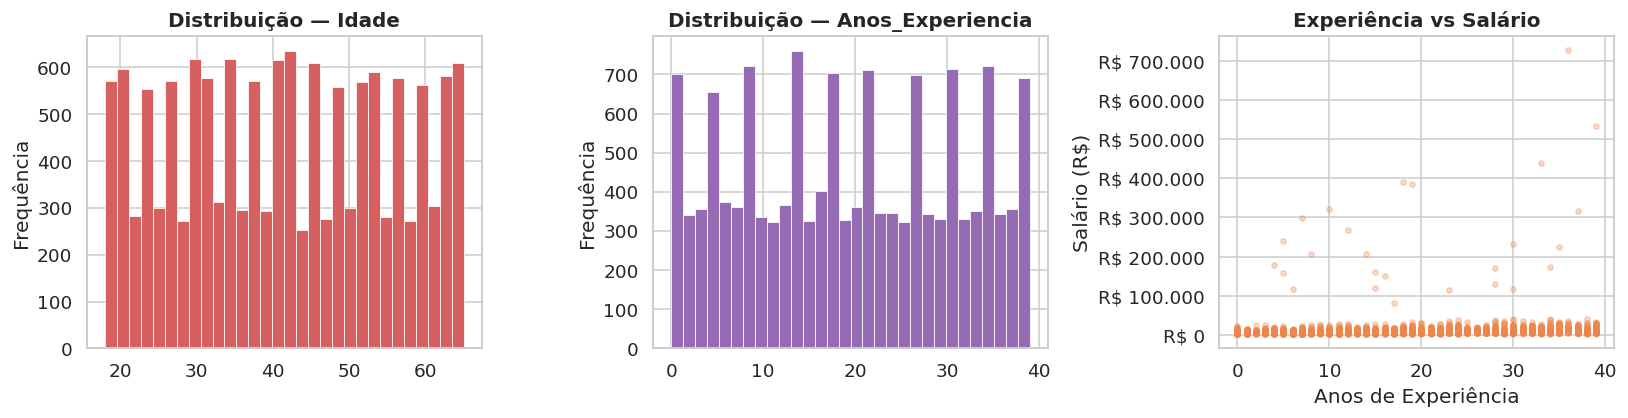

Correlação Experiência × Salário: 0.095
Correlação Idade × Salário       : 0.008



In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cores = sns.color_palette("muted")

for ax, col, cor in zip(axes[:2], ["Idade", "Anos_Experiencia"], cores[3:]):
    ax.hist(df[col].dropna(), bins=30, color=cor, edgecolor="white", linewidth=0.5)
    ax.set_title(f"Distribuição — {col}")
    ax.set_ylabel("Frequência")

# Scatter Experiência vs Salário (sample para não pesar o plot)
amostra = df.sample(2000, random_state=SEED)
axes[2].scatter(amostra["Anos_Experiencia"], amostra["Salario"],
                alpha=0.3, s=12, color=cores[1])
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[2].set_xlabel("Anos de Experiência")
axes[2].set_ylabel("Salário (R$)")
axes[2].set_title("Experiência vs Salário")

plt.tight_layout()
plt.show()

print(f"Correlação Experiência × Salário: {df['Anos_Experiencia'].corr(df['Salario']):.3f}")
print(f"Correlação Idade × Salário       : {df['Idade'].corr(df['Salario']):.3f}")
print()

## 5. Variáveis Categóricas

### 5.1 Escolaridade

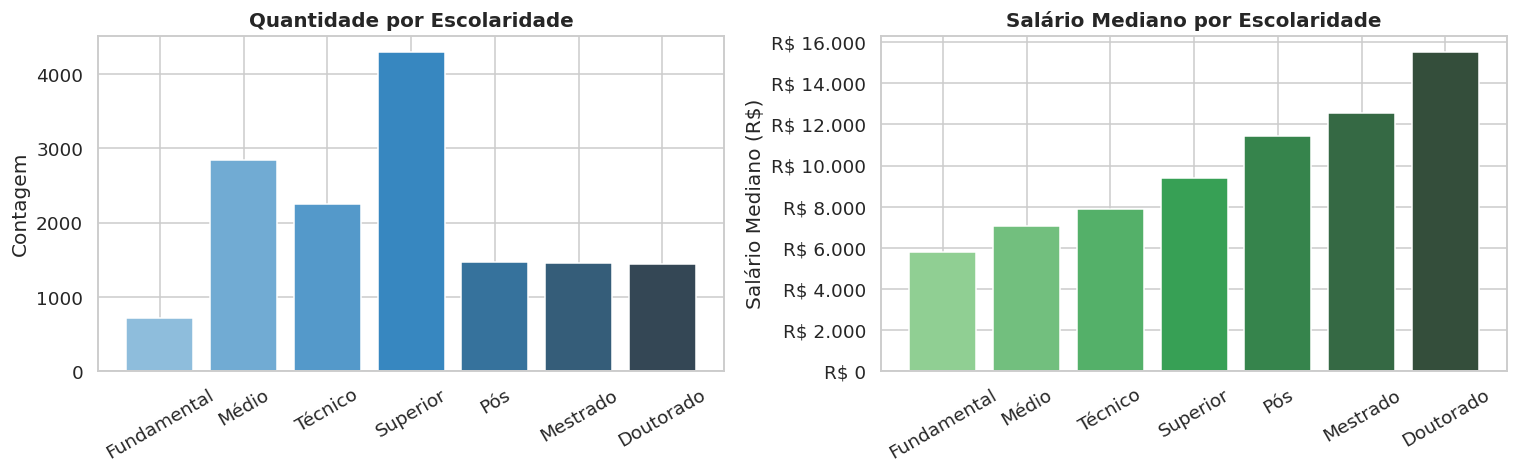

In [19]:
ordem_esc = ["Fundamental", "Médio", "Técnico", "Superior", "Pós", "Mestrado", "Doutorado"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Contagem
contagem = df["Escolaridade"].value_counts().reindex(ordem_esc)
axes[0].bar(contagem.index, contagem.values,
            color=sns.color_palette("Blues_d", len(ordem_esc)), edgecolor="white")
axes[0].set_title("Quantidade por Escolaridade")
axes[0].set_ylabel("Contagem")
axes[0].tick_params(axis="x", rotation=30)

# Mediana do salário por escolaridade
med_esc = df.groupby("Escolaridade")["Salario"].median().reindex(ordem_esc)
axes[1].bar(med_esc.index, med_esc.values,
            color=sns.color_palette("Greens_d", len(ordem_esc)), edgecolor="white")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[1].set_title("Salário Mediano por Escolaridade")
axes[1].set_ylabel("Salário Mediano (R$)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


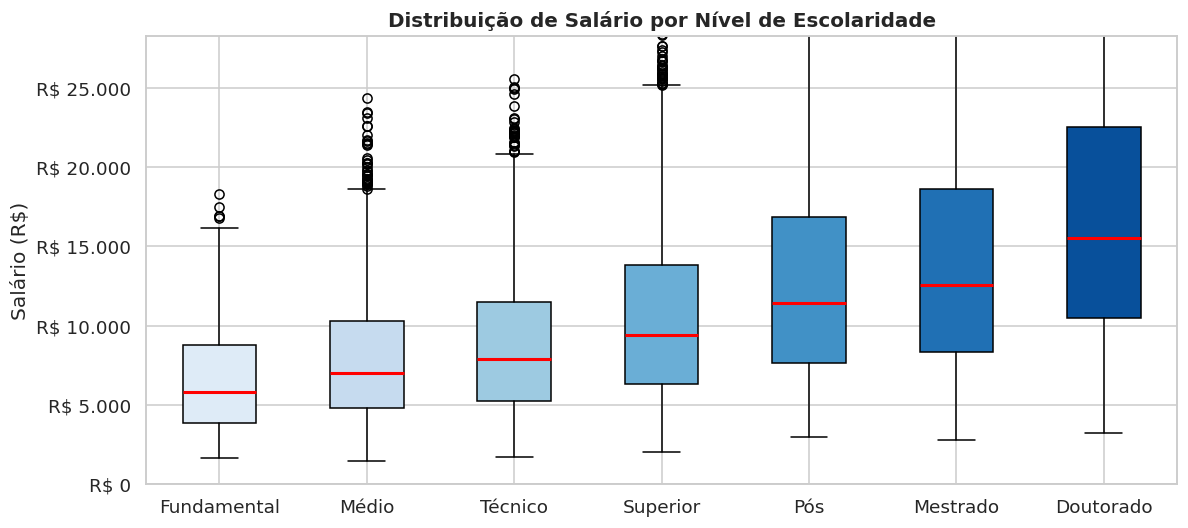

→ Há uma tendência de aumento salarial com a escolaridade,
  mas com grande sobreposição entre os níveis.


In [20]:
# Boxplot detalhado
fig, ax = plt.subplots(figsize=(11, 5))
dados_esc = [df[df["Escolaridade"] == e]["Salario"].dropna().values for e in ordem_esc]
bp = ax.boxplot(dados_esc, labels=ordem_esc, patch_artist=True,
                medianprops=dict(color="red", linewidth=2))

cores_box = sns.color_palette("Blues", len(ordem_esc))
for patch, cor in zip(bp["boxes"], cores_box):
    patch.set_facecolor(cor)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title("Distribuição de Salário por Nível de Escolaridade")
ax.set_ylabel("Salário (R$)")
ax.set_ylim(0, df["Salario"].quantile(0.97))
plt.tight_layout()
plt.show()

print("→ Há uma tendência de aumento salarial com a escolaridade,")
print("  mas com grande sobreposição entre os níveis.")


### 5.2 Região

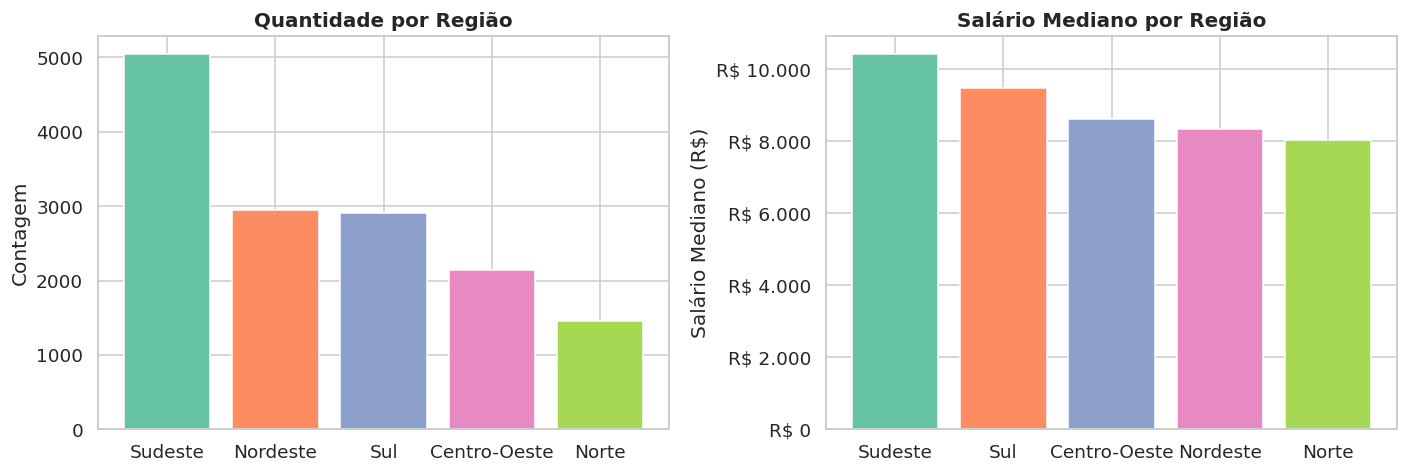

Salário mediano por região:
  Sudeste        : R$ 10,400
  Sul            : R$ 9,469
  Centro-Oeste   : R$ 8,608
  Nordeste       : R$ 8,338
  Norte          : R$ 8,036


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Contagem por região
cnt_reg = df["Regiao"].value_counts()
axes[0].bar(cnt_reg.index, cnt_reg.values,
            color=sns.color_palette("Set2"), edgecolor="white")
axes[0].set_title("Quantidade por Região")
axes[0].set_ylabel("Contagem")

# Mediana salarial por região
med_reg = df.groupby("Regiao")["Salario"].median().sort_values(ascending=False)
cores_reg = sns.color_palette("Set2", len(med_reg))
axes[1].bar(med_reg.index, med_reg.values, color=cores_reg, edgecolor="white")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
axes[1].set_title("Salário Mediano por Região")
axes[1].set_ylabel("Salário Mediano (R$)")

plt.tight_layout()
plt.show()

print("Salário mediano por região:")
for reg, val in med_reg.items():
    print(f"  {reg:<15}: R$ {val:,.0f}")


### 5.3 Profissão

In [ ]:
med_prof = df.groupby("Profissao")["Salario"].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores_prof = sns.color_palette("coolwarm", len(med_prof))
ax.barh(med_prof.index, med_prof.values, color=cores_prof, edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title("Salário Mediano por Profissão")
ax.set_xlabel("Salário Mediano (R$)")

plt.tight_layout()
plt.show()


### 5.4 Idiomas

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, titulo in zip(axes,
    ["Segunda_Lingua", "Terceira_Lingua"],
    ["Segunda Língua", "Terceira Língua"]):
    cnt = df[col].value_counts()
    ax.pie(cnt.values, labels=cnt.index, autopct="%1.1f%%",
           colors=sns.color_palette("pastel"), startangle=140)
    ax.set_title(titulo)

plt.suptitle("Distribuição de Idiomas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Impacto de falar línguas no salário
df["total_linguas"] = (
    (df["Segunda_Lingua"]  != "Nenhuma").astype(int) +
    (df["Terceira_Lingua"] != "Nenhuma").astype(int)
)

med_ling = df.groupby("total_linguas")["Salario"].median()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["0 línguas extra", "1 língua extra", "2 línguas extra"],
       med_ling.values,
       color=sns.color_palette("muted"), edgecolor="white")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax.set_title("Salário Mediano × Número de Idiomas Adicionais")
ax.set_ylabel("Salário Mediano (R$)")
plt.tight_layout()
plt.show()

for n, v in med_ling.items():
    print(f"  {n} idioma(s) extra: R$ {v:,.0f}")


## 6. Correlações e Relações entre Variáveis

In [ ]:
# Encoding simples para calcular correlações
df_corr = df.copy()
df_corr["Escolaridade_cod"] = pd.Categorical(
    df_corr["Escolaridade"], categories=["Fundamental","Médio","Técnico","Superior","Pós","Mestrado","Doutorado"]
).codes
df_corr["tem_segunda_lingua"]  = (df_corr["Segunda_Lingua"]  != "Nenhuma").astype(int)
df_corr["tem_terceira_lingua"] = (df_corr["Terceira_Lingua"] != "Nenhuma").astype(int)

cols_corr = ["Idade", "Anos_Experiencia", "Escolaridade_cod",
             "tem_segunda_lingua", "tem_terceira_lingua", "total_linguas", "Salario"]
corr_matrix = df_corr[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, mask=mask, ax=ax, linewidths=0.5,
            annot_kws={"size": 10})
ax.set_title("Matriz de Correlação (variáveis numéricas)")
plt.tight_layout()
plt.show()

print("→ Escolaridade tem a maior correlação positiva com Salário.")
print("→ Idade e Experiência têm correlação muito fraca isoladamente.")


In [ ]:
# Salário vs Escolaridade vs Região (heatmap cruzado)
pivot = df.groupby(["Regiao", "Escolaridade"])["Salario"].median().unstack()
pivot = pivot.reindex(columns=["Fundamental","Médio","Técnico","Superior","Pós","Mestrado","Doutorado"])

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Salário Mediano (R$) — Região × Escolaridade")
ax.set_xlabel("Escolaridade")
ax.set_ylabel("Região")
plt.tight_layout()
plt.show()


In [ ]:
# Top 5 profissoes: distribuicao salarial detalhada
top5 = df.groupby("Profissao")["Salario"].median().nlargest(5).index.tolist()
bot5 = df.groupby("Profissao")["Salario"].median().nsmallest(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grupo, titulo, cor in zip(
    axes,
    [top5, bot5],
    ["Top 5 Profissões (maior salário)", "Bottom 5 Profissões (menor salário)"],
    ["Blues_r", "Oranges_r"]
):
    dados = [df[df["Profissao"] == p]["Salario"].dropna().values for p in grupo]
    bp = ax.boxplot(dados, labels=grupo, patch_artist=True,
                    medianprops=dict(color="red", linewidth=2))
    palette = sns.color_palette(cor, 5)
    for patch, c in zip(bp["boxes"], palette):
        patch.set_facecolor(c)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(0, df["Salario"].quantile(0.97))

plt.tight_layout()
plt.show()


## 7. Insights e Conclusões para a Modelagem

---

### 🔍 Problemas encontrados

| Problema | Quantidade | Tratamento |
|---|---|---|
| Salário = `"erro"` | 200 registros | Converter para NaN e remover |
| Salário nulo | 297 registros | Remover (não se imputa target) |
| Salário = 0 ou negativo | 0 registros | — |
| Outliers extremos (> p99.5 = R\$225k) | 73 registros | Remover |
| Idade nula | 489 registros (3.3%) | Imputar com mediana |
| Anos_Experiencia nulo | 498 registros (3.3%) | Imputar com mediana |

---

### 📈 Distribuição do target

- O salário tem **distribuição fortemente assimétrica** (skewness positivo).
- Coeficiente de variação = 2.12 → dispersão extremamente alta.
- **`log1p(Salário)` transforma a distribuição para próxima da normal** → melhora significativa nos modelos de regressão.

---

### 🔗 Relações com o salário

| Variável | Observação |
|---|---|
| **Profissão** | Maior impacto: Advogado/Médico/Engenheiro ≈ 3–4× Motorista/Vendedor |
| **Escolaridade** | Correlação positiva clara — Doutorado mediana ≈ 2× Fundamental |
| **Região** | Sudeste paga mais; Norte paga menos (diferença ≈ 30%) |
| **Idiomas** | Impacto modesto mas consistente |
| **Idade** | Correlação quase nula isoladamente |
| **Experiência** | Correlação fraca (0.09) — mediada pela profissão |

---

### ⚙️ Decisões de modelagem tomadas com base na EDA

1. **Target**: `log1p(Salario)` → revertido com `expm1()` na predição
2. **Outliers**: remover acima do p99.5
3. **Escolaridade**: OrdinalEncoder (hierarquia clara)
4. **Profissão e Região**: OneHotEncoder (sem ordem)
5. **Idiomas**: features derivadas (`tem_segunda`, `tem_terceira`, `total`)
6. **Nulos numéricos**: SimpleImputer com mediana

---

> *"Os dados raramente mentem, mas precisam ser interpretados com cuidado."*
